# ECON N171: Economic Development
## Lecture 10 — Instrumental Variables
**Instructor: Rajveer Jat | Summer 2026**

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. Explain why OLS is biased when the key variable is **endogenous**
2. State the two conditions for a **valid instrument**: relevance and exclusion
3. Implement **2SLS manually** to understand the two-stage logic
4. Run correct IV estimation using `linearmodels`
5. Test for **weak instruments** using the first-stage F-statistic
6. Interpret the **LATE** — what IV actually estimates

---

## The Economic Question: Returns to Education

How much does an additional year of schooling raise wages?

This is one of the most studied questions in labor economics — and one of the hardest to answer causally.

### The OLS Model

$$\log(\text{wage}_i) = \alpha + \beta \cdot \text{schooling}_i + \varepsilon_i$$

### Why OLS is Biased: Ability Bias

People with higher **innate ability** tend to:
- Stay in school longer (more schooling)
- Earn higher wages (directly, regardless of schooling)

Ability is **unobserved** — it ends up in $\varepsilon_i$. But it is **correlated** with schooling. So $E[\text{schooling}_i \cdot \varepsilon_i] \neq 0$ — OLS is biased **upward**.

### The Instrument: Distance to College

**Card (1995)** uses distance to the nearest college as an instrument for schooling:
- **Relevance**: people who grow up near a college get more schooling (lower cost)
- **Exclusion**: distance to college affects wages *only through* schooling — not directly

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

!pip install linearmodels -q
from linearmodels.iv import IV2SLS

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11
print('Libraries loaded.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 8.7 MB/s eta 0:00:00
Libraries loaded.


---
## Part 1: Generate Data with Known True Parameters

We simulate data where **we know the truth** — the true return to schooling is **8% per year**.
This lets us see exactly how much OLS is biased and how IV corrects it.

In [2]:
np.random.seed(42)
n = 3000

# TRUE parameter
TRUE_RETURN = 0.08   # 8% wage increase per year of schooling

# Unobserved ability: correlated with schooling but not with instrument
ability = np.random.normal(0, 1, n)

# Instrument: distance to nearest college (km), lower = closer = more schooling
# Assigned independently of ability (exclusion restriction holds)
dist_college = np.random.uniform(5, 100, n)

# Schooling: driven by ability AND distance to college
# Closer to college (lower dist) → more schooling
schooling = np.clip(
    12 + 1.5 * ability - 0.04 * dist_college + np.random.normal(0, 1.5, n),
    6, 20
).round()

# Log wages: true return = 8%, also affected by ability DIRECTLY
log_wage = (
    1.0
    + TRUE_RETURN * schooling
    + 0.20 * ability          # ability directly raises wages (the source of OLS bias)
    + np.random.normal(0, 0.3, n)
)

df = pd.DataFrame({
    'log_wage'    : log_wage.round(4),
    'schooling'   : schooling,
    'dist_college': dist_college.round(1),
    'ability'     : ability.round(4),   # unobserved in real life
})

print('Dataset:', df.shape)
print(f'Mean schooling:         {df["schooling"].mean():.1f} years')
print(f'Mean log wage:          {df["log_wage"].mean():.3f}')
print(f'Mean distance (km):     {df["dist_college"].mean():.1f}')
print(f'True return to school:  {TRUE_RETURN:.0%} per year')
df.head()

Dataset: (3000, 4)
Mean schooling:         10.0 years
Mean log wage:          1.803
Mean distance (km):     52.0
True return to school:  8% per year


,log_wage,schooling,dist_college,ability
0,2.0826,9.0,82.8,0.4967
1,1.5578,6.0,98.4,-0.1383
2,2.4201,14.0,29.7,0.6477
3,2.2195,10.0,97.1,1.5230
4,2.1611,9.0,46.0,-0.2342


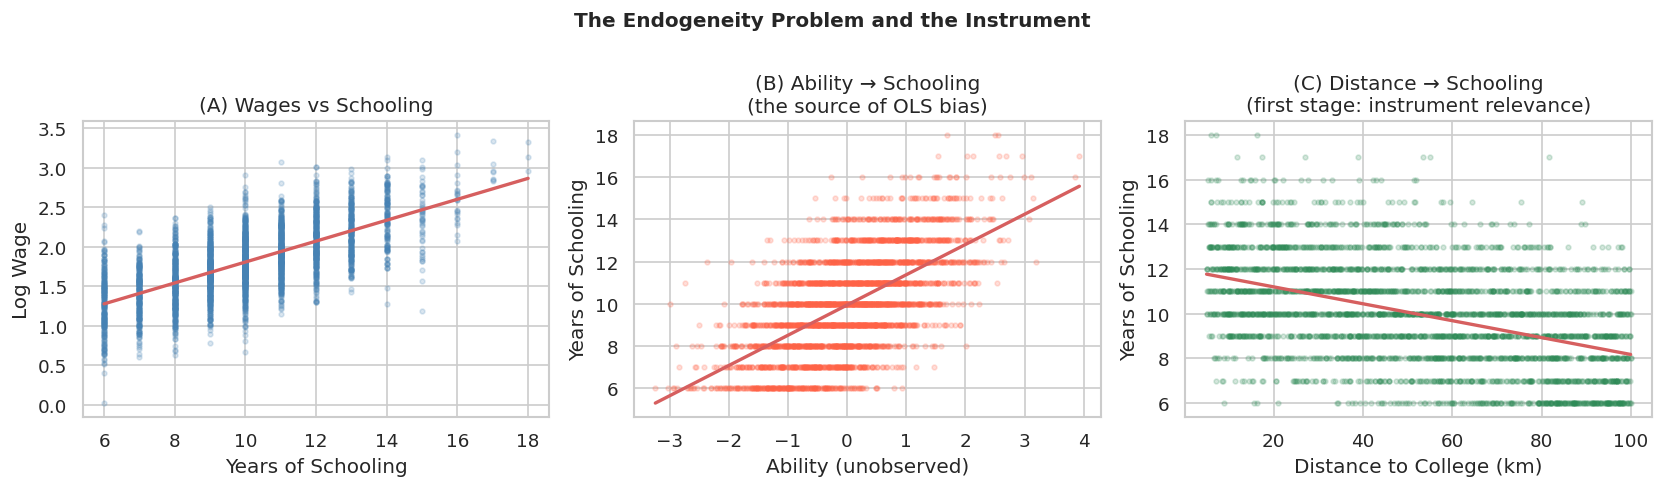

In [3]:
# Visualize the endogeneity problem
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Wages vs schooling
axes[0].scatter(df['schooling'], df['log_wage'], alpha=0.2, s=8, color='steelblue')
z = np.polyfit(df['schooling'], df['log_wage'], 1)
x_l = np.linspace(df['schooling'].min(), df['schooling'].max(), 100)
axes[0].plot(x_l, np.poly1d(z)(x_l), 'r-', linewidth=2)
axes[0].set_xlabel('Years of Schooling')
axes[0].set_ylabel('Log Wage')
axes[0].set_title('(A) Wages vs Schooling')

# Ability vs schooling (the problem)
axes[1].scatter(df['ability'], df['schooling'], alpha=0.2, s=8, color='tomato')
z2 = np.polyfit(df['ability'], df['schooling'], 1)
x_l2 = np.linspace(df['ability'].min(), df['ability'].max(), 100)
axes[1].plot(x_l2, np.poly1d(z2)(x_l2), 'r-', linewidth=2)
axes[1].set_xlabel('Ability (unobserved)')
axes[1].set_ylabel('Years of Schooling')
axes[1].set_title('(B) Ability → Schooling\n(the source of OLS bias)')

# Distance vs schooling (first stage)
axes[2].scatter(df['dist_college'], df['schooling'], alpha=0.2, s=8, color='seagreen')
z3 = np.polyfit(df['dist_college'], df['schooling'], 1)
x_l3 = np.linspace(df['dist_college'].min(), df['dist_college'].max(), 100)
axes[2].plot(x_l3, np.poly1d(z3)(x_l3), 'r-', linewidth=2)
axes[2].set_xlabel('Distance to College (km)')
axes[2].set_ylabel('Years of Schooling')
axes[2].set_title('(C) Distance → Schooling\n(first stage: instrument relevance)')

plt.suptitle('The Endogeneity Problem and the Instrument',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Part 2: OLS — Biased Estimate

OLS will overestimate the return to schooling because ability is positively correlated with both schooling and wages.

In [4]:
# OLS: naive regression (what a researcher without IV would do)
m_ols = smf.ols('log_wage ~ schooling', data=df).fit()

ols_coef = m_ols.params['schooling']
ols_se   = m_ols.bse['schooling']
ols_p    = m_ols.pvalues['schooling']

print('=== OLS: Return to Schooling ===')
print(f'  Coefficient: {ols_coef:.4f}')
print(f'  Std Error:   {ols_se:.4f}')
print(f'  p-value:     {ols_p:.4f}')
print()
print(f'  OLS estimate:  {ols_coef:.1%} per year of schooling')
print(f'  True return:   {TRUE_RETURN:.1%} per year of schooling')
print(f'  Upward bias:   {ols_coef - TRUE_RETURN:.1%}')
print()
print('OLS is biased upward because high-ability people get more schooling')
print('AND earn more — ability confounds the estimate.')

=== OLS: Return to Schooling ===
  Coefficient: 0.1324
  Std Error:   0.0026
  p-value:     0.0000

  OLS estimate:  13.2% per year of schooling
  True return:   8.0% per year of schooling
  Upward bias:   5.2%

OLS is biased upward because high-ability people get more schooling
AND earn more — ability confounds the estimate.


In [5]:
# What if we could control for ability? (we can here because it's simulated)
m_ols_ability = smf.ols('log_wage ~ schooling + ability', data=df).fit()
coef_with_ability = m_ols_ability.params['schooling']

print('=== OLS with Ability Controlled (benchmark — not possible in real data) ===')
print(f'  Coefficient: {coef_with_ability:.4f}')
print(f'  True return: {TRUE_RETURN:.4f}')
print(f'  Bias when ability controlled: {coef_with_ability - TRUE_RETURN:.4f}')
print()
print('When we control for ability, OLS recovers the true return.')
print('But in real data, ability is unobserved — this is why we need IV.')

=== OLS with Ability Controlled (benchmark — not possible in real data) ===
  Coefficient: 0.0814
  True return: 0.0800
  Bias when ability controlled: 0.0014

When we control for ability, OLS recovers the true return.
But in real data, ability is unobserved — this is why we need IV.


---
## Part 3: The Instrument — Two Conditions

### Condition 1: Relevance
The instrument must predict the endogenous variable. We test this with the **first-stage F-statistic**. Rule of thumb: F > 10.

### Condition 2: Exclusion Restriction
The instrument must affect wages **only through schooling** — not directly. This is an **assumption** — we cannot test it directly. We must argue it on economic grounds.

For distance to college:
- ✅ Distance affects schooling (closer = cheaper to attend)
- ✅ Distance has no direct effect on wages (employers don't care where you grew up)
- ❓ Potential violation: cities with colleges may have better labor markets

In [6]:
# Check relevance: first stage
first_stage = smf.ols('schooling ~ dist_college', data=df).fit()

print('=== First Stage: Distance → Schooling ===')
print(f'  Coefficient on distance: {first_stage.params["dist_college"]:+.4f}')
print(f'  (Each 10km further reduces schooling by {abs(first_stage.params["dist_college"])*10:.2f} years)')
print(f'  F-statistic: {first_stage.fvalue:.2f}')
print(f'  R-squared:   {first_stage.rsquared:.4f}')
print()
if first_stage.fvalue > 10:
    print('  ✅ Strong instrument: F > 10')
else:
    print('  ⚠️  Weak instrument: F < 10 — IV estimates will be unreliable')
print()

# Check exclusion: is distance correlated with ability? (it shouldn't be)
corr_dist_ability = df['dist_college'].corr(df['ability'])
print(f'  Correlation: distance vs ability = {corr_dist_ability:.4f}')
print('  (Should be near 0 — instrument assigned independently of ability)')

=== First Stage: Distance → Schooling ===
  Coefficient on distance: -0.0378
  (Each 10km further reduces schooling by 0.38 years)
  F-statistic: 740.38
  R-squared:   0.1980

  ✅ Strong instrument: F > 10

  Correlation: distance vs ability = 0.0096
  (Should be near 0 — instrument assigned independently of ability)


---
## Part 4: Manual 2SLS — Understanding the Logic

**Stage 1**: Regress schooling on the instrument → get predicted schooling (`schooling_hat`)

$$\widehat{\text{schooling}}_i = \hat{\pi}_0 + \hat{\pi}_1 \cdot \text{distance}_i$$

**Stage 2**: Regress log wages on predicted schooling

$$\log(\text{wage}_i) = \alpha + \beta \cdot \widehat{\text{schooling}}_i + \varepsilon_i$$

**Why does this work?** Predicted schooling varies only because of distance — which is unrelated to ability. We have stripped out the ability-driven variation in schooling, leaving only the exogenous part.

In [7]:
# Stage 1: predict schooling from instrument
stage1 = smf.ols('schooling ~ dist_college', data=df).fit()
df['schooling_hat'] = stage1.fittedvalues

print('Stage 1 fitted values (first 5):')
print(df[['schooling', 'dist_college', 'schooling_hat']].head())
print()
print('Note: schooling_hat varies ONLY because of distance to college.')
print('It has no ability component — the endogeneity is removed.')

Stage 1 fitted values (first 5):
   schooling  dist_college  schooling_hat
0        9.0          82.8       8.822618
1        6.0          98.4       8.232250
2       14.0          29.7      10.832139
3       10.0          97.1       8.281448
4        9.0          46.0      10.215280

Note: schooling_hat varies ONLY because of distance to college.
It has no ability component — the endogeneity is removed.


In [8]:
# Stage 2: regress wages on PREDICTED schooling
stage2 = smf.ols('log_wage ~ schooling_hat', data=df).fit()

iv_manual_coef = stage2.params['schooling_hat']

print('=== Manual 2SLS: Return to Schooling ===')
print(f'  Stage 2 coefficient: {iv_manual_coef:.4f}')
print()
print(f'  True return:   {TRUE_RETURN:.4f}')
print(f'  OLS estimate:  {ols_coef:.4f}  (biased upward)')
print(f'  IV estimate:   {iv_manual_coef:.4f}  (closer to truth)')
print()
print('⚠️ WARNING: Standard errors from manual 2SLS are WRONG.')
print('The stage 2 SE does not account for the fact that schooling_hat')
print('is estimated, not observed. Always use linearmodels for correct SEs.')


=== Manual 2SLS: Return to Schooling ===
  Stage 2 coefficient: 0.0810

  True return:   0.0800
  OLS estimate:  0.1324  (biased upward)
  IV estimate:   0.0810  (closer to truth)

⚠️ WARNING: Standard errors from manual 2SLS are WRONG.
The stage 2 SE does not account for the fact that schooling_hat
is estimated, not observed. Always use linearmodels for correct SEs.


(When you run stage 2 manually, Python treats schooling_hat as fixed known data — but it was estimated in stage 1 and carries its own uncertainty. The OLS formula in stage 2 ignores this, producing standard errors that are too small and p-values that are too significant. linearmodels solves both stages simultaneously using the correct formula that accounts for both sources of uncertainty. Manual 2SLS is only for building intuition — never use it for inference.)

---
## Part 5: Correct IV with linearmodels

In [9]:
# Correct 2SLS with proper standard errors
exog  = sm.add_constant(pd.DataFrame(index=df.index))  # intercept only
endog = df[['schooling']]
instr = df[['dist_college']]
dep   = df['log_wage']

iv_model = IV2SLS(dep, exog, endog, instr).fit(cov_type='robust')

iv_coef = float(iv_model.params['schooling'])
iv_se   = float(iv_model.std_errors['schooling'])
iv_p    = float(iv_model.pvalues['schooling'])
iv_ci   = iv_model.conf_int().loc['schooling']

print('=== IV (linearmodels): Correct Standard Errors ===')
print(f'  Coefficient:     {iv_coef:.4f}')
print(f'  Std Error:       {iv_se:.4f}')
print(f'  p-value:         {iv_p:.4f}')
print(f'  95% CI:          [{float(iv_ci.iloc[0]):.4f}, {float(iv_ci.iloc[1]):.4f}]')
print()
print(f'  IV estimate:  {iv_coef:.1%} per year of schooling')
print(f'  True return:  {TRUE_RETURN:.1%} per year of schooling')

=== IV (linearmodels): Correct Standard Errors ===
  Coefficient:     0.0810
  Std Error:       0.0061
  p-value:         0.0000
  95% CI:          [0.0691, 0.0929]

  IV estimate:  8.1% per year of schooling
  True return:  8.0% per year of schooling


---
## Part 6: What Happens with a Weak Instrument?

A weak instrument (low F-stat) produces unreliable IV estimates — wide confidence intervals, possible bias in the direction of OLS. Let's see this directly.

In [10]:
# Simulate a weak instrument (very noisy, barely predicts schooling)
weak_instrument = -0.002 * df['dist_college'] + np.random.normal(0, 5, n)  # mostly noise
df['weak_inst'] = weak_instrument

# First stage with weak instrument
fs_weak = smf.ols('schooling ~ weak_inst', data=df).fit()
print(f'Weak instrument F-stat: {fs_weak.fvalue:.2f}  (should be << 10)')

# IV with weak instrument
iv_weak = IV2SLS(dep, exog, df[['weak_inst']], instr).fit(cov_type='robust')

# Wait — linearmodels needs instrument for schooling
iv_weak2 = IV2SLS(dep, exog, endog, df[['weak_inst']]).fit(cov_type='robust')
iv_weak_coef = float(iv_weak2.params['schooling'])
iv_weak_se   = float(iv_weak2.std_errors['schooling'])

print()
print('=== Comparison: Strong vs Weak Instrument ===')
print(f'{"":30s} {"Coef":>8} {"SE":>8} {"F-stat":>8}')
print('-' * 56)
print(f'{"True return":30s} {TRUE_RETURN:>8.4f}')
print(f'{"OLS":30s} {ols_coef:>8.4f} {ols_se:>8.4f}')
print(f'{"IV (strong instrument)":30s} {iv_coef:>8.4f} {iv_se:>8.4f} {first_stage.fvalue:>8.1f}')
print(f'{"IV (weak instrument)":30s} {iv_weak_coef:>8.4f} {iv_weak_se:>8.4f} {fs_weak.fvalue:>8.1f}')
print()
print('Weak instrument: large SE, unreliable estimate, may be closer to OLS bias.')

Weak instrument F-stat: 0.37  (should be << 10)

=== Comparison: Strong vs Weak Instrument ===
                                   Coef       SE   F-stat
--------------------------------------------------------
True return                      0.0800
OLS                              0.1324   0.0026
IV (strong instrument)           0.0810   0.0061    740.4
IV (weak instrument)            -0.3990   0.9146      0.4

Weak instrument: large SE, unreliable estimate, may be closer to OLS bias.


---
## Part 7: The Full Picture — OLS vs IV Comparison

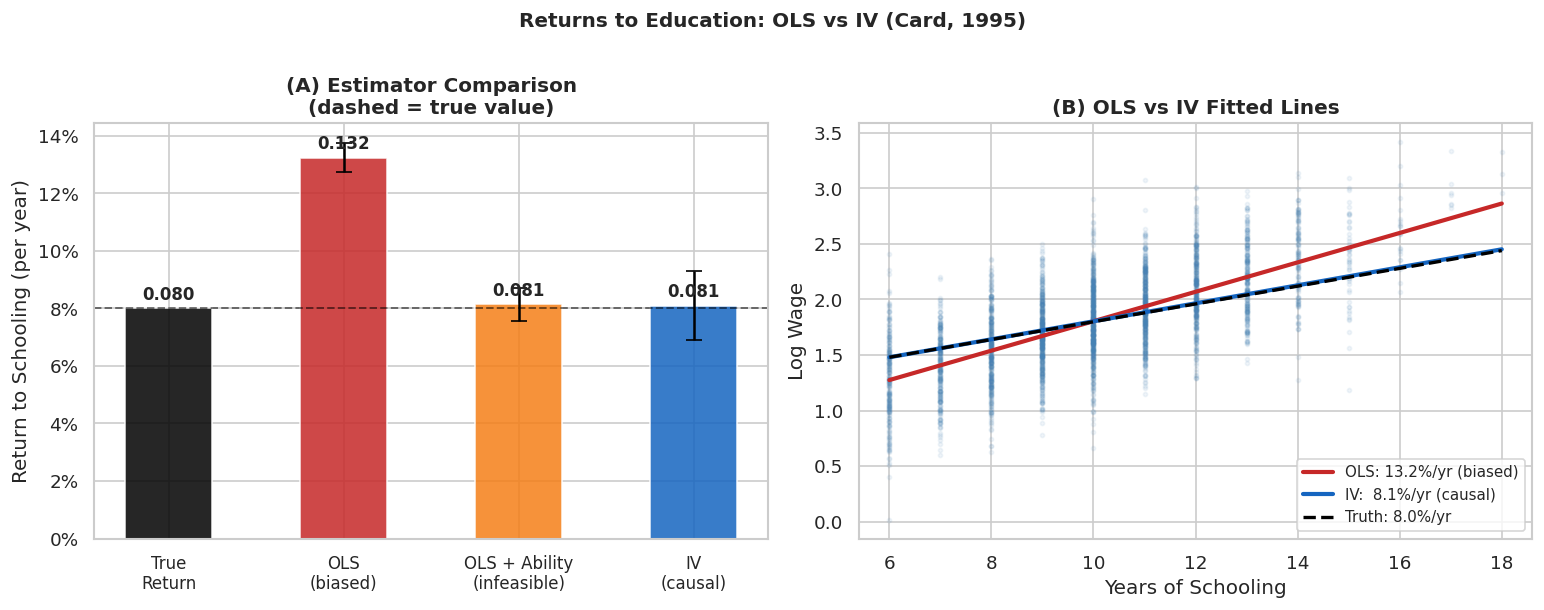

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: coefficient comparison
labels = ['True\nReturn', 'OLS\n(biased)', 'OLS + Ability\n(infeasible)', 'IV\n(causal)']
coefs  = [TRUE_RETURN, ols_coef, coef_with_ability, iv_coef]
ses    = [0, ols_se, m_ols_ability.bse['schooling'], iv_se]
colors = ['black', '#C62828', '#F57F17', '#1565C0']

x = np.arange(len(labels))
bars = axes[0].bar(x, coefs, color=colors, edgecolor='white', width=0.5, alpha=0.85)
axes[0].errorbar(x[1:], coefs[1:], yerr=1.96*np.array(ses[1:]),
                 fmt='none', color='black', capsize=5, linewidth=1.5)
for i, (c, lab) in enumerate(zip(coefs, labels)):
    axes[0].text(i, c + 0.003, f'{c:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[0].axhline(TRUE_RETURN, color='black', linestyle='--', linewidth=1.2, alpha=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=10)
axes[0].set_ylabel('Return to Schooling (per year)')
axes[0].set_title('(A) Estimator Comparison\n(dashed = true value)', fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Right: the two-stage logic visually
# Show OLS fit vs IV fit on the data
x_sch = np.linspace(df['schooling'].min(), df['schooling'].max(), 100)
axes[1].scatter(df['schooling'], df['log_wage'], alpha=0.08, s=6, color='steelblue')
axes[1].plot(x_sch, m_ols.params['Intercept'] + ols_coef * x_sch,
             color='#C62828', linewidth=2.5, label=f'OLS: {ols_coef:.1%}/yr (biased)')
axes[1].plot(x_sch, iv_model.params['const'] + iv_coef * x_sch,
             color='#1565C0', linewidth=2.5, label=f'IV:  {iv_coef:.1%}/yr (causal)')
axes[1].plot(x_sch, 1.0 + TRUE_RETURN * x_sch,
             color='black', linewidth=2, linestyle='--', label=f'Truth: {TRUE_RETURN:.1%}/yr')
axes[1].set_xlabel('Years of Schooling')
axes[1].set_ylabel('Log Wage')
axes[1].set_title('(B) OLS vs IV Fitted Lines', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Returns to Education: OLS vs IV (Card, 1995)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Part 8: LATE — What Does IV Actually Estimate?

IV does not estimate the **Average Treatment Effect (ATE)** — the effect for everyone.

IV estimates the **Local Average Treatment Effect (LATE)** — the effect for **compliers**: people whose schooling was affected by the instrument.

In our example: LATE = return to schooling for people who got more education **because they lived close to a college**.

This may differ from the ATE:
- People induced to study by proximity may be **different** from the average student
- They may have lower ability on average (they needed the nudge)
- Their return to education may be **lower** than average

In [12]:
# Illustrate LATE: who are the compliers?
# Compliers: people whose schooling changed because of the instrument
# Proxy: people near college (within 30km) vs far (beyond 70km)

near = df[df['dist_college'] <= 30]
far  = df[df['dist_college'] >= 70]

print('=== Complier Analysis ===')
print()
print(f'  Near college (≤30km):  mean schooling = {near["schooling"].mean():.1f} yrs,  mean ability = {near["ability"].mean():.3f}')
print(f'  Far from college (≥70km): mean schooling = {far["schooling"].mean():.1f} yrs,  mean ability = {far["ability"].mean():.3f}')
print()
print(f'  Schooling difference (near - far): {near["schooling"].mean() - far["schooling"].mean():.2f} years')
print(f'  Ability difference (near - far):   {near["ability"].mean() - far["ability"].mean():.3f}')
print()
print('The instrument (distance) is independent of ability — good exclusion restriction.')
print('But it does induce more schooling for those near colleges.')
print()
print('IV (LATE) estimates the return to schooling for this marginal group.')
print('This is policy-relevant: it answers "what happens when we build a college nearby?"')

=== Complier Analysis ===

  Near college (≤30km):  mean schooling = 11.3 yrs,  mean ability = 0.002
  Far from college (≥70km): mean schooling = 8.7 yrs,  mean ability = 0.031

  Schooling difference (near - far): 2.54 years
  Ability difference (near - far):   -0.029

The instrument (distance) is independent of ability — good exclusion restriction.
But it does induce more schooling for those near colleges.

IV (LATE) estimates the return to schooling for this marginal group.
This is policy-relevant: it answers "what happens when we build a college nearby?"


---
## Summary

### The IV Recipe

| Step | What you do | Python code |
|------|------------|-------------|
| 1. Find instrument | Argue relevance + exclusion | — |
| 2. First stage | Regress endogenous var on instrument | `smf.ols('X ~ Z').fit()` |
| 3. Check F-stat | Must be > 10 | `result.fvalue` |
| 4. Run IV | Get correct SEs | `IV2SLS(y, exog, X, Z).fit()` |
| 5. Compare OLS vs IV | Assess direction of bias | Plot or table |

### Key Concepts

- **Endogeneity**: $E[X \cdot \varepsilon] \neq 0$ — OLS is biased
- **Instrument validity**: relevance ($Z$ predicts $X$) + exclusion ($Z$ only affects $y$ through $X$)
- **First stage F-stat**: > 10 = strong instrument; < 10 = weak instrument (unreliable IV)
- **2SLS logic**: use only the exogenous variation in $X$ predicted by $Z$
- **LATE**: IV estimates the effect for **compliers** — not the whole population
- **Manual 2SLS SE is wrong**: always use `linearmodels` for correct standard errors

### Why IV Matters for Development Economics

Almost every policy-relevant question in development involves endogeneity:
- Do dams reduce poverty? (dams built in specific places)
- Does education raise wages? (ability bias)
- Does migration help the poor? (who self-selects to migrate)
- Does infrastructure cause growth? (built where growth is expected)

IV is the workhorse solution to all of these — when you can find a valid instrument.

---
*ECON N171 | Summer 2026*